# Filling Gaps with model results

In the previous tutorial, we learnt to fill gaps left by monitoring stations using satellite images. Another alternative to satellite images is model results.

Scientists use satellite data, monitoring data, emissions inventories, machine learning and atmospheric modeling to produce estimates on what could be a pollutant's concentration in any given grid. A grid is nothing but a square pixel on ground.

In this tutorial we will use [SatPM2.5, a model output](https://sites.wustl.edu/acag/surface-pm2-5/#V6.GL.02.04) produced by the [Washington University at St.Louis (WUSTL)](https://washu.edu/). 

## Understanding the model outputs

This [model output](https://sites.wustl.edu/acag/surface-pm2-5/#V6.GL.02.04) estimated the mean concentration of PM2.5 (μg/m3), at monthly and annual resolutions, globally. The estimates are available at both `0.01°` and `0.1°` spatial resolutions. 0.01° roughly corresponds to 1km and 0.1° roughly corresponds to 11km.

The [model output](https://sites.wustl.edu/acag/surface-pm2-5/#V6.GL.02.04)  is available to download in the form of `NetCDF` file. This is standard format in which a lot of modeling results are shared by the scientific community. We can work with `NetCDF` files using `xarray` library on python.

In this tutorial, we will download 2023's annual mean PM2.5 concentration (μg/m3) `NetCDF` file of 0.01° resolution for Asia (AS) region: [V6GL02.04.CNNPM25.AS.202301-202312.nc](https://wustl.app.box.com/s/y143mciw7jz7ft2qe3hccjw65m3xe8f2/file/1904255351863). The file is ~90MB in size. We will crop out the grids from Delhi and see the `PM2.5` pollution in Delhi.

In [16]:
import xarray as xr
import geopandas as gpd

In [17]:
# Open the downloaded NetCDF file
ds = xr.open_dataset('data/V6GL02.04.CNNPM25.AS.202301-202312.nc', chunks={})
ds

<xarray.Dataset> Size: 224MB
Dimensions:  (lat: 7000, lon: 8000)
Coordinates:
  * lat      (lat) float32 28kB -9.995 -9.985 -9.975 ... 59.97 59.99 59.99
  * lon      (lon) float32 32kB 65.0 65.01 65.03 65.04 ... 145.0 145.0 145.0
Data variables:
    PM25     (lat, lon) float32 224MB dask.array<chunksize=(1750, 2000), meta=np.ndarray>
Attributes:
    TITLE:            Convolutional Neural Network Annual PM2.5 Estimation ov...
    CONTACT:          SIYUAN SHEN <s.siyuan@wustl.edu>
    LAT_DELTA:        0.01
    LON_DELTA:        0.01
    SPATIALCOVERAGE:  AS
    TIMECOVERAGE:     2023

Lets take sometime to understand the `NetCDF` file. We can read that this file has one Data variables `PM25`. We can also see that there are `lat` and `lon` co-ordinates. They are latitudes and longitudes of the centre of each pixel.

We can look at the `PM25` Data Array to get a better sense of how the data is organised:

In [18]:
ds['PM25']

<xarray.DataArray 'PM25' (lat: 7000, lon: 8000)> Size: 224MB
dask.array<open_dataset-PM25, shape=(7000, 8000), dtype=float32, chunksize=(1750, 2000), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 28kB -9.995 -9.985 -9.975 ... 59.97 59.99 59.99
  * lon      (lon) float32 32kB 65.0 65.01 65.03 65.04 ... 145.0 145.0 145.0
Attributes:
    units:      ug/m3
    long_name:  Convolutional Neural Network derived Annual PM2.5 [ug/m^3]

The `PM25` data is organised in the form of a 2-dimensional matrix. The `lat` and `lon` map the surface of Asia using 8000*7000 grids.

## Cropping the model results to geography of Interest

The above model result is for all Asia. In this tutorial, we are only interested to know the `PM2.5` levels in Delhi. You can use any other geojson of interest.

In [20]:
delhi_districts = gpd.read_file('data/DELHI_DISTRICTS.geojson')

In [21]:
# We assign the CRS explicitly
ds = ds.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
ds = ds.rio.write_crs("EPSG:4326")

In [22]:
# Ensure that both Delhi file and Netcdf file has same CRS
delhi_districts = delhi_districts.to_crs(ds.rio.crs)

In [23]:
# Get the bounding box coordinates of Delhi
minx, miny, maxx, maxy = delhi_districts.total_bounds

#Crop the netcdf to the bounding box
clipped = ds.rio.clip_box(
    minx=minx,
    miny=miny,
    maxx=maxx,
    maxy=maxy
)

In [25]:
pm25 = clipped['PM25']
pm25

<xarray.DataArray 'PM25' (lat: 49, lon: 52)> Size: 10kB
dask.array<getitem, shape=(49, 52), dtype=float32, chunksize=(49, 52), chunktype=numpy.ndarray>
Coordinates:
  * lat          (lat) float32 196B 28.41 28.42 28.42 ... 28.86 28.88 28.89
  * lon          (lon) float32 208B 76.83 76.85 76.86 ... 77.32 77.33 77.35
    spatial_ref  int64 8B 0
Attributes:
    units:      ug/m3
    long_name:  Convolutional Neural Network derived Annual PM2.5 [ug/m^3]

We can see that the number of `lat` and `lon` reduced. This is because we cropped the `NetCDF` to Delhi region.

## Plotting the model results for Delhi

The DataArray can be easily visualised using the `.plot()` function.

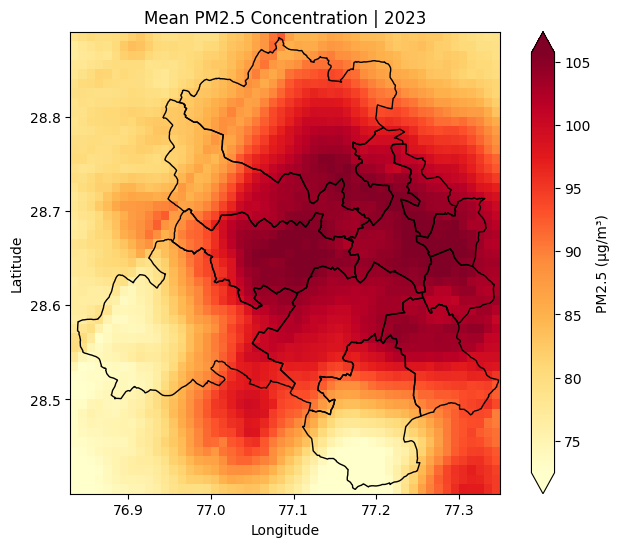

In [26]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(8,6))

# plot pm2.5 raster
pm25.plot(
    ax=ax,
    cmap="YlOrRd",
    robust=True,
    cbar_kwargs={"label": "PM2.5 (µg/m³)"}
)

# overlay boundary
delhi_districts.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1
)

# labels and title
ax.set_title("Mean PM2.5 Concentration | 2023")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

We can also save this matrix as a `TIF` file and plot it in the same way we [plotted satellite images](https://urbanemissionsinfo.github.io/AirQualityVisuals/notebooks/Plotting_SatelliteImages.html).

In [90]:
# Write the GeoTIFF
pm25.rio.to_raster('meanpm25_delhi_wustl_2023.tif')

## Analysis with model results

### Which grid in India has met Air Quality Standards in 2024?

We can also do more analysis with such modeling results.

For example, we want to know which 0.01°x0.01° grid in India has met the [Air Quality Standards](https://urbanemissionsinfo.github.io/AQCourse/notebooks/Air_Quality_Standards.html) for `PM2.5` pollutant, in the year 2023. For this, we crop the `NetCDF` file to India, instead of Delhi. Here, we'll learn to crop exactly to India instead of India's bounding box.

In [41]:
india = gpd.read_file("data/INDIA_STATES.geojson")
india = india.to_crs(ds.rio.crs)

In [42]:
#Crop the netcdf to the bounding box
clipped = ds.rio.clip(india.geometry, india.crs)

In [43]:
pm25_india = clipped['PM25']
pm25_india

<xarray.DataArray 'PM25' (lat: 3034, lon: 2923)> Size: 35MB
dask.array<getitem, shape=(3034, 2923), dtype=float32, chunksize=(1750, 1682), chunktype=numpy.ndarray>
Coordinates:
  * lat          (lat) float32 12kB 6.755 6.765 6.775 ... 37.06 37.08 37.08
  * lon          (lon) float32 12kB 68.18 68.19 68.21 68.21 ... 97.39 97.39 97.4
    spatial_ref  int64 8B 0
Attributes:
    units:      ug/m3
    long_name:  Convolutional Neural Network derived Annual PM2.5 [ug/m^3]

In [44]:
#Convert all negatives pm25 values to NULL
pm25_india = pm25_india.where(pm25_india >= 0)

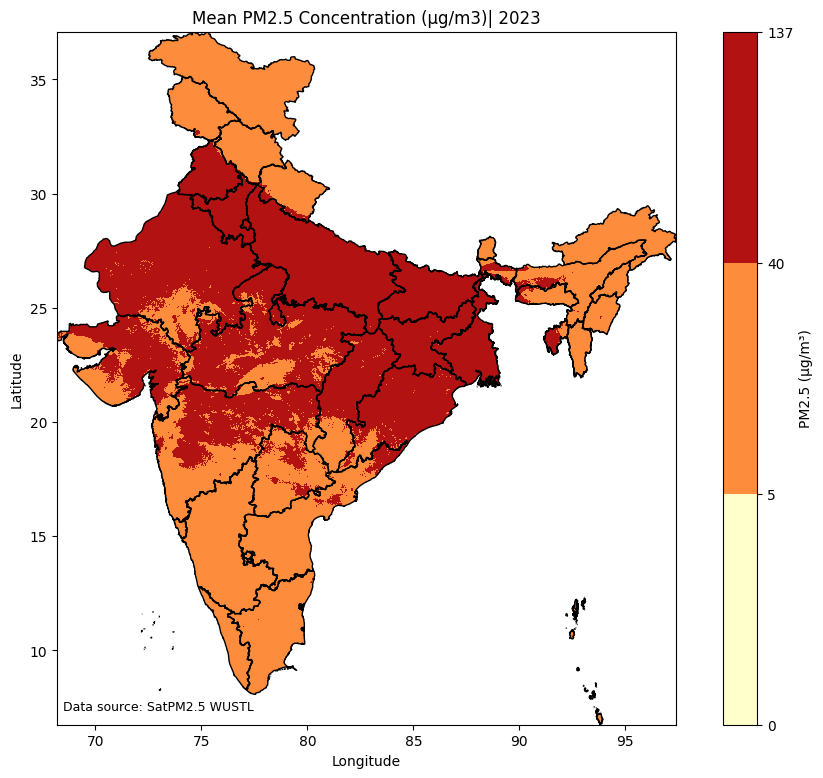

In [58]:
#Plot the mean with required color mapping

# define class breaks
max_val = pm25_india.max().compute().item()
bounds = [0, 5, 40, round(max_val)] #WHO Standard, NAAQS

# choose 3 colors
#cmap = plt.get_cmap("YlOrRd", 3)
cmap = mcolors.ListedColormap([
    "#FFFFCC",   # Less than WHO guideline
    "#FD8D3C",   # Less than NAAQS 
    "#b31212"    # More than NAAQS
])
norm = mcolors.BoundaryNorm(bounds, cmap.N)


# plot pm2.5 raster
fig, ax = plt.subplots(figsize=(12,9))
pm25_india.plot(
    ax=ax,
    cmap=cmap,
    norm=norm,
    cbar_kwargs={
        "label": "PM2.5 (µg/m³)",
        "ticks": bounds
    }
)

# overlay boundary
india.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1
)

# labels and title
ax.set_title("Mean PM2.5 Concentration (μg/m3)| 2023")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# data source annotation
ax.text(
    0.01, 0.02,
    "Data source: SatPM2.5 WUSTL",
    transform=ax.transAxes,
    fontsize=9,
    color="black"
)
plt.savefig('pm25mean_india_2023.png')
plt.show()

In [49]:
min_val = pm25_india.min().compute().item()

print(f"The minimum PM2.5 concentration in any grid in India is {round(min_val,2)}  μg/m3")

The minimum PM2.5 concentration in any grid in India is 9.17  μg/m3


As per this modeling result, there is no  0.01°x0.01° grid in India that met W.H.O guideline of 5 μg/m3, in 2023.

## Summary

In this tutorial, we learnt about model outputs and how to work with `NetCDF` files. We learnt to crop and plot model results to a geography of interest. We also learnt how we can analyse model results to ask various research and policy questions. 